# Evaluating Model Performance

In [2]:
# IMPORT LIBRARIES AND CONFIGURE PATHS
# Core scientific computing libraries for data analysis
import numpy as np          # Numerical operations and array handling
import scipy as sc          #
# Scientific computing functions (filtering, etc.)
import pandas as pd         # Data manipulation and analysis

# Visualization library
import matplotlib.pyplot as plt  # Plotting and figure generation
import seaborn as sns

# System and file handling utilities
from os.path import join as ospj  # Cross-platform path joining
# from utils import *               # Custom utility functions

# Load configuration paths and settings
from config import Config
# Extract key paths: raw data, processed data, metadata, figures, and patient IDs
datapath, prodatapath, metapath, figpath, rid_hup = Config.deal(['datapath','prodatapath','metapath','figpath','rid_hup'])

## NDD heritage

In [3]:
ndd_old = pd.read_csv(ospj(prodatapath,'res_series_list_ndd.csv'))

<Axes: xlabel='hidden_size', ylabel='test_r2'>

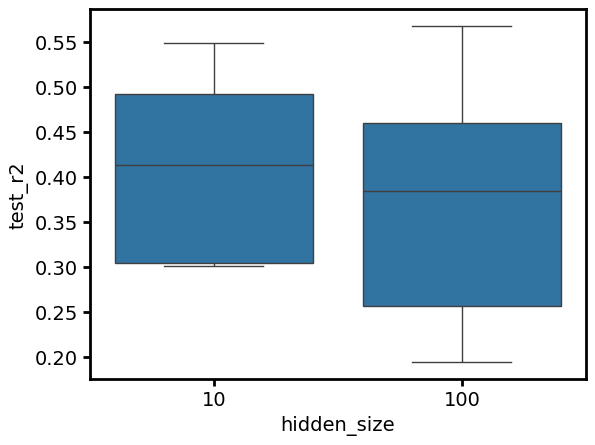

In [4]:
sns.boxplot(ndd_old[ndd_old['duration']==60],x='hidden_size',y='test_r2')

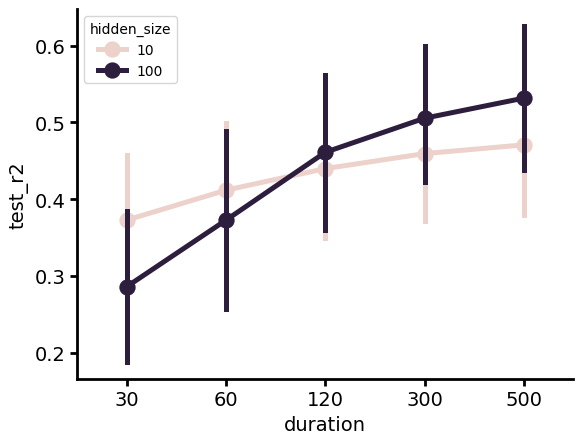

In [5]:
sns.pointplot(x='duration',hue='hidden_size',y='test_r2',data=ndd_old[ndd_old['forecast_length']==1],legend=True)
sns.despine()

## MINDD hyperparameter optimization

In [6]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP276')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.2,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2   hidden_sizes     weights  sequence_length
838  0.846805  0.965526  0.903373  [23808, 3571]    (2, 0.3)              128
363  0.845000  0.958604  0.898688         [9523]      (0.8,)              128
350  0.841300  0.963947  0.899778   [9523, 3571]  (0.8, 0.3)              128
482  0.838377  0.955403  0.894399  [23808, 5952]    (2, 0.5)              128
146  0.836983  0.947585  0.888647         [5952]        (1,)               64
686  0.836541  0.951603  0.890698         [5952]      (0.5,)              128
274  0.826928  0.943451  0.882598        [11904]        (1,)              128
644  0.825952  0.941971  0.880302         [3571]      (0.3,)              128
411  0.824927  0.933344  0.875037         [4761]      (0.8,)               64
259  0.814732  0.938007  0.873368   [5952, 5952]  (0.5, 0.5)              128
816  0.814342  0.937076  0.872548   [5952, 9523]  (0.5, 0.8)              128
545  0.814245  0.933374  0.871234  [11904, 5952]    (1, 0.5)    

In [7]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP065')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.3,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2  hidden_sizes     weights  sequence_length
534  0.858744  0.902651  0.894761   [2816, 422]    (2, 0.3)              128
788  0.840073  0.860177  0.874863   [2816, 704]    (2, 0.5)              128
844  0.831381  0.816321  0.866048  [1126, 2816]    (0.8, 2)              128
23   0.828822  0.808358  0.860316  [1126, 1126]  (0.8, 0.8)              128
20   0.828103  0.803983  0.860048  [1126, 1408]    (0.8, 1)              128
228  0.824571  0.816775  0.857192  [2816, 1126]    (2, 0.8)              128
746  0.817343  0.794082  0.846728   [1126, 422]  (0.8, 0.3)              128
715  0.816621  0.786109  0.847647        [2816]        (2,)              128
603  0.816537  0.782077  0.845812   [1126, 704]  (0.8, 0.5)              128
287  0.812146  0.776206  0.843029  [1408, 1126]    (1, 0.8)              128
208  0.809768  0.755488  0.836746        [1408]        (1,)              128
850  0.804837  0.760632  0.834478   [1408, 704]    (1, 0.5)              128

In [8]:
group_cols = ['sequence_length','weights']
ndd_data_avg = mindd_results.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,weights,train_r2,val_r2,test_r2
0,128,"(2, 0.3)",0.902651,0.894761,0.858744


## NDD System Identification

In [9]:
# ndd_data = pd.read_csv(ospj(prodatapath,'res_series_list_deep.csv'))
# ndd_data['model'] = ndd_data['model'].apply(lambda x: x.split('.')[-1][:-2])

In [10]:
ndd_data = pd.read_csv(ospj(prodatapath,'compiled_ndd_optimization_results.csv'))
# ndd_data = ndd_data[ndd_data['patient']=='HUP065']
gin_data = ndd_data[ndd_data['model']=='GIN']
lin_data = ndd_data[ndd_data['model']=='LiNDDA']
min_data = ndd_data[ndd_data['model']=='MINDD']
lir_data = ndd_data[ndd_data.model=='LiRNDDA']

In [11]:
ndd_data.patient.nunique()

5

<Axes: xlabel='duration', ylabel='test_r2'>

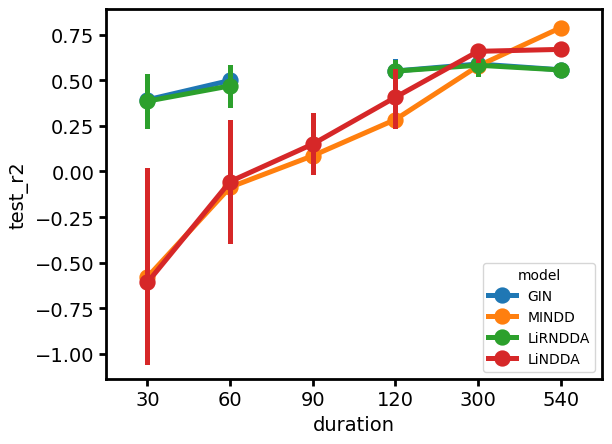

In [12]:
sns.pointplot(x='duration',hue='model',y='test_r2',data=ndd_data[ndd_data['sequence_length']==128])

In [13]:
group_cols = ['sequence_length','num_layers','num_stacks']
ndd_data_avg = gin_data[gin_data.duration == 120].groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,num_layers,num_stacks,train_r2,val_r2,test_r2
0,32,1.0,1.0,0.455521,0.53808,0.574985


<Axes: xlabel='sequence_length', ylabel='test_r2'>

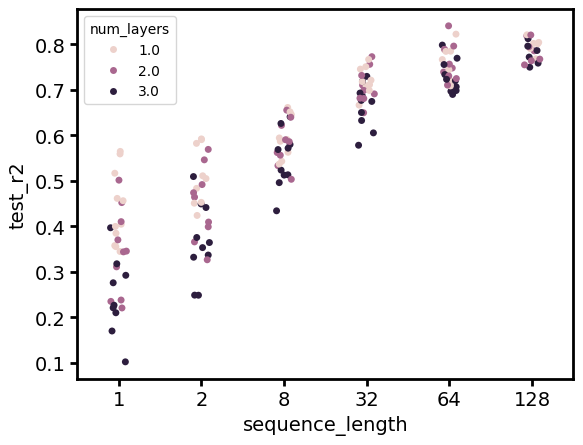

In [14]:
sns.stripplot(x='sequence_length',y='test_r2',hue='num_layers',data=min_data[min_data['duration']==540])

<Axes: xlabel='sequence_length', ylabel='train_s'>

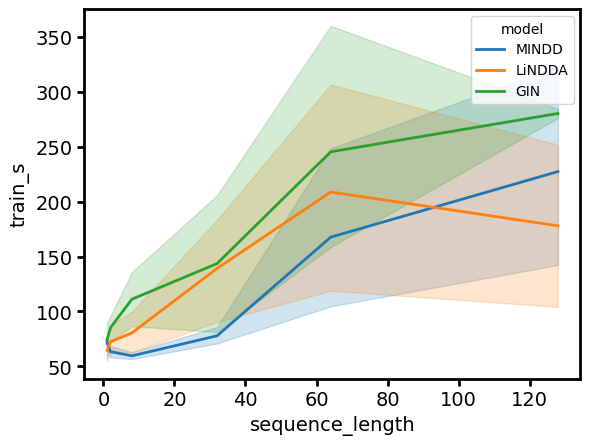

In [15]:
sns.lineplot(x='sequence_length',hue='model',y='train_s',data=ndd_data[(ndd_data['duration']==540)&(ndd_data.model != 'LiRNDDA')])

<Axes: xlabel='sequence_length', ylabel='test_r2'>

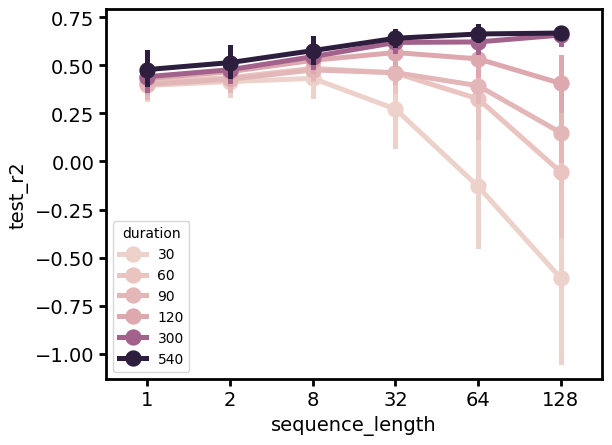

In [16]:
sns.pointplot(lin_data,x='sequence_length',hue='duration',y='test_r2')

(0.0, 1.0)

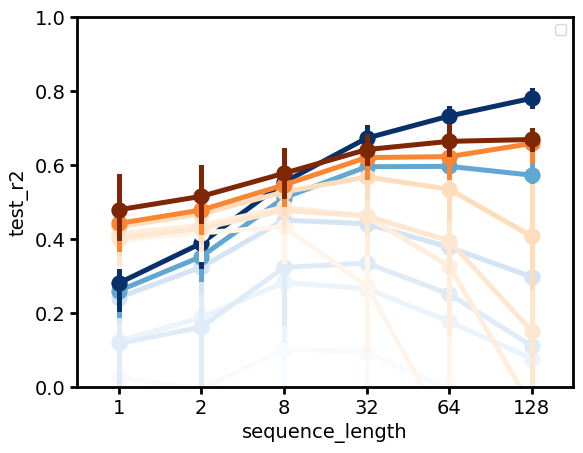

In [17]:
sns.pointplot(min_data[(min_data['param_scale']==1)],x='sequence_length',y='test_r2',hue='duration',palette='Blues')
sns.pointplot(lin_data,x='sequence_length',y='test_r2',hue='duration',palette='Oranges')
plt.legend([])
plt.ylim(0,1)

In [18]:
group_cols = ['model','duration','sequence_length','num_layers','param_scale','num_stacks','forecast_length']
ndd_data_avg = ndd_data.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
for model in ndd_data_avg['model'].unique():
    for duration in ndd_data_avg['duration'].unique():
        subset = ndd_data_avg[(ndd_data_avg['model'] == model) & (ndd_data_avg['duration'] == duration)]
        if subset.empty: continue
        max_r2 = subset['test_r2'].max()
        best = subset[subset['test_r2'] == max_r2]
        best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['model','duration','sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()


,model,duration,sequence_length,num_layers,param_scale,num_stacks,forecast_length,train_r2,val_r2,test_r2
0,GIN,30,64,1.0,NaN,1.0,1,0.378659,0.394394,0.409219
1,GIN,60,32,1.0,NaN,1.0,1,0.434224,0.462267,0.507847
2,GIN,120,32,1.0,NaN,1.0,1,0.455521,0.538080,0.574985
3,GIN,300,128,1.0,NaN,1.0,1,0.469911,0.551114,0.588645
4,GIN,540,32,1.0,NaN,1.0,1,0.471488,0.606583,0.608054
5,LiNDDA,30,8,NaN,NaN,NaN,1,0.434550,0.504924,0.432667
6,LiNDDA,60,8,NaN,NaN,NaN,1,0.431026,0.511783,0.484901
10,LiNDDA,90,8,NaN,NaN,NaN,1,0.425589,0.504898,0.476701
7,LiNDDA,120,32,NaN,NaN,NaN,1,0.527712,0.622853,0.567271
8,LiNDDA,300,128,NaN,NaN,NaN,1,0.630197,0.677594,0.657976


<Axes: xlabel='sequence_length', ylabel='test_r2'>

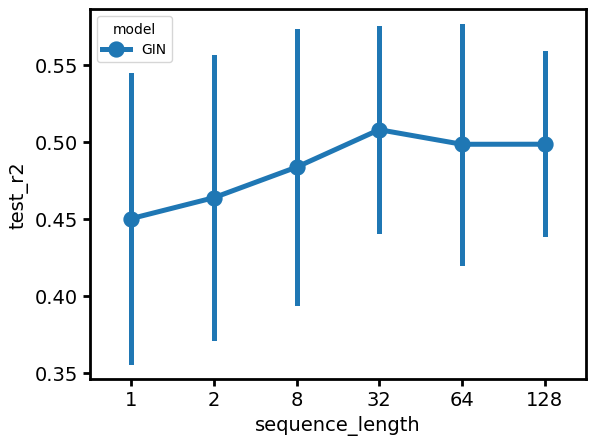

In [19]:
sns.pointplot(x='sequence_length',hue='model',y='test_r2',data=gin_data[(gin_data['duration']==60)])

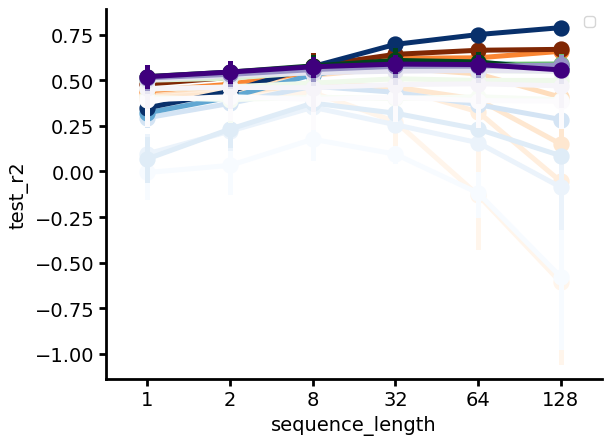

In [20]:
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lin_data[lin_data['forecast_length']==1],palette='Oranges')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=min_data[min_data['forecast_length']==1],palette='Blues')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=gin_data[gin_data['forecast_length']==1],palette='Greens')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lir_data[lir_data['forecast_length']==1],palette='Purples')
plt.legend([])
sns.despine()

<Axes: xlabel='model', ylabel='train_s'>

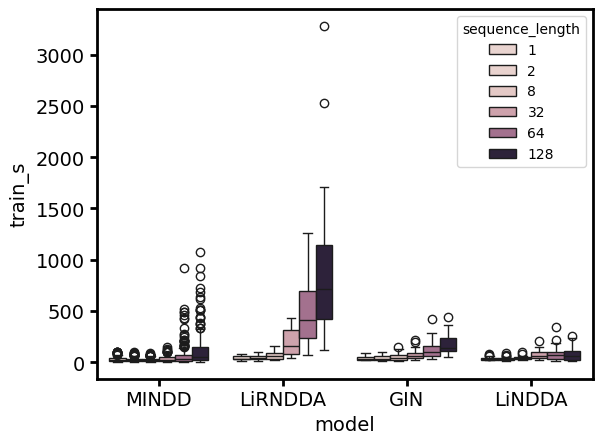

In [21]:
sns.boxplot(x='model',hue='sequence_length',y='train_s',data=ndd_data)

## Validation performance

In [19]:
shallow_data = pd.read_csv(ospj(prodatapath, "benchmark_model_validation_results.csv"))
shallow_melted = pd.melt(shallow_data, id_vars=['model'], value_vars=['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall'], var_name='metric', value_name='value')

In [20]:
shallow_data.onset.nunique()

1037

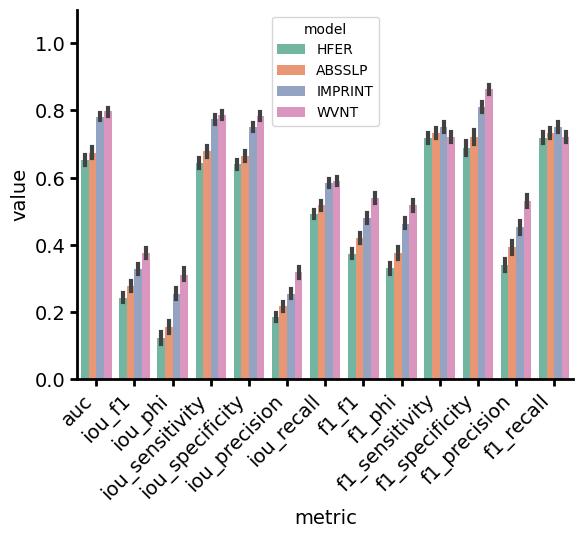

In [21]:
# sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette=['purple','blue','green','red'],hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])

# sns.stripplot(x='metric',y='value',hue='model',data=shallow_melted, dodge=True, jitter=True,alpha=0.1,color='gray',size=3,legend=False)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
sns.despine()

In [24]:
# sns.barplot(x='model',y='threshold',data=shallow_data,palette=['blue','green','red'])
# sns.stripplot(x='model',y='threshold',data=shallow_data, dodge=True, jitter=True,alpha=0.1,color='gray',size=3)
# sns.despine()
iou_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index().groupby('model').agg({'iou_threshold':'mean'}).reset_index()
f1_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'f1_threshold':'mean'}).reset_index().groupby('model').agg({'f1_threshold':'mean'}).reset_index()
phi_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'phi_threshold':'mean'}).reset_index().groupby('model').agg({'phi_threshold':'mean'}).reset_index()
print(iou_benchmark_thresholds)
print(f1_benchmark_thresholds)
print(phi_benchmark_thresholds)

     model  iou_threshold
0   ABSSLP     266.664839
1     HFER      45.882461
2  IMPRINT      14.549651
3     WVNT       0.398021
     model  f1_threshold
0   ABSSLP    286.282302
1     HFER     49.217325
2  IMPRINT     17.555568
3     WVNT      0.466021
     model  phi_threshold
0   ABSSLP     297.250971
1     HFER      52.426548
2  IMPRINT      16.297232
3     WVNT       0.489462


<Axes: ylabel='iou_threshold'>

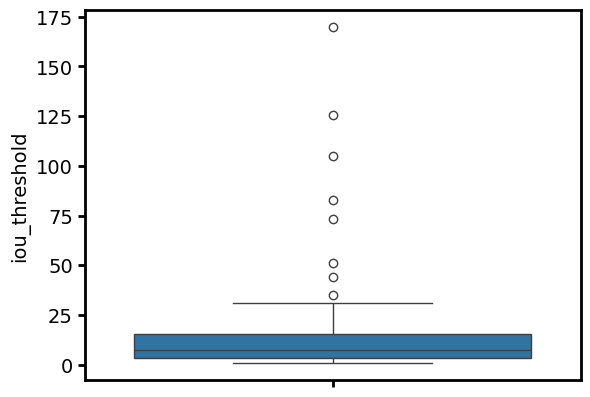

In [28]:
sns.boxplot(shallow_data[shallow_data.model == 'IMPRINT'].groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index()['iou_threshold'])

In [30]:
f1_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_f1.csv'))
iou_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_iou.csv'))
phi_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_phi.csv'))

## Generalized Validation performance

In [ ]:
val_data = pd.read_csv(ospj(prodatapath, "benchmark_val_analysis_results_f1.csv"))

In [30]:
val_data.onset.nunique()

1030

In [31]:
val_data_onset = val_data.melt(id_vars=['patient','model'], value_vars=['sensitivity','specificity','f1','phi'], var_name='metric', value_name='value')
val_data_spread = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_spread_rank_pct','avg_soz_spread_rank_pct'], var_name='metric', value_name='value')
val_data_latency = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_recruitment_latency','avg_soz_recruitment_latency'], var_name='metric', value_name='value')

/tmp/ipykernel_37417/4198091649.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


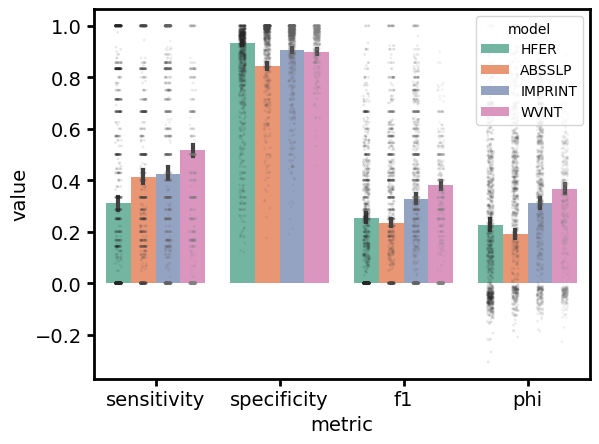

/tmp/ipykernel_37417/4198091649.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


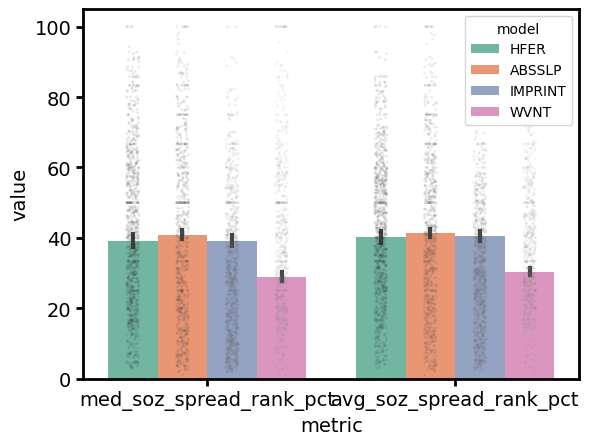

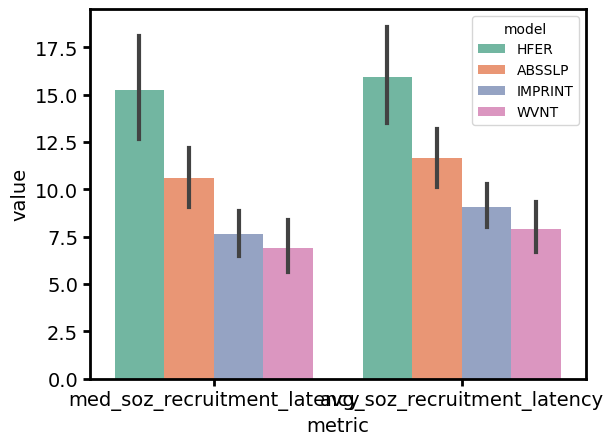

In [32]:
sns.barplot(x='metric',y='value',hue='model',data=val_data_onset,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_spread,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_latency,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
# sns.stripplot(x='metric',y='value',hue='model',data=val_data_latency,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

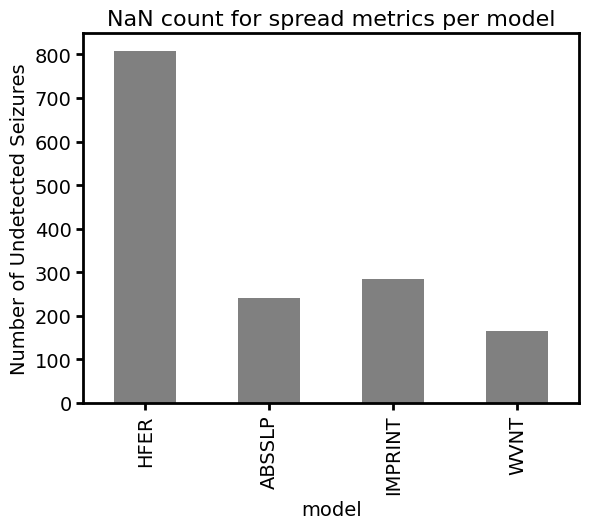

In [33]:
spread_nan_counts = val_data_spread[val_data_spread['value'].isna()].groupby('model').size()
spread_nan_counts = spread_nan_counts.reindex(['HFER','ABSSLP','IMPRINT','WVNT']).fillna(0)
spread_nan_counts.plot(kind='bar',color='gray')
plt.ylabel('Number of Undetected Seizures')
plt.title('NaN count for spread metrics per model')
plt.show()


## NDD performance

Initial rows: 11904

Metadata duplicates on 'onset': 6
Metadata duplicates on ['patient','onset']: 0
After first merge: 11904 rows

Total duplicate rows: 0

After deduplication: 11904 rows


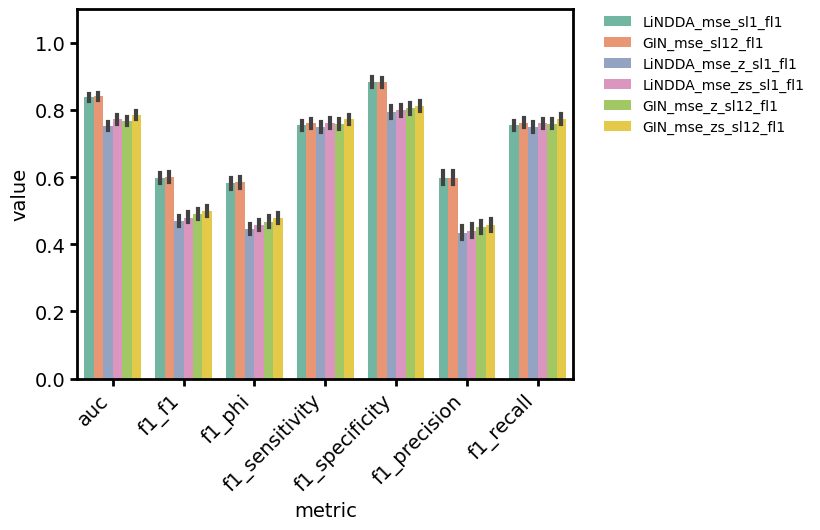

In [19]:
# ndd_data = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results.csv'))
# ndd_data_latter = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter.csv'))
# ndd_data_lat_server = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter_server.csv'))

# ndd_data = pd.concat([ndd_data,ndd_data_latter,ndd_data_lat_server])
# ndd_data_32 = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32.csv'))
# ndd_data_32s = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32_server.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_32,ndd_data_32s])
# ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_100.csv'))
# mindd_data = pd.read_csv(ospj(prodatapath,f"mindd_model_validation_results_100.csv"))
# ndd_data = pd.concat([ndd_data,mindd_data])
ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v3.csv'))
# ndd_data_temp = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v2_linddaseq.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_temp])
print(f"Initial rows: {len(ndd_data)}")

metadata = pd.read_csv(ospj(metapath,'metadata_v6_BIDS.csv'))
metadata['patient'] = metadata['Patient']
metadata['stim'] = metadata['stim'].fillna(0)
metadata['onset'] = metadata['onset'].astype(int)

print(f"\nMetadata duplicates on 'onset': {metadata['onset'].duplicated().sum()}")
print(f"Metadata duplicates on ['patient','onset']: {metadata[['patient','onset']].duplicated().sum()}")

# First merge
ndd_data = ndd_data.merge(metadata[['patient', 'onset', 'stim']], on=['patient', 'onset'], how='left')
print(f"After first merge: {len(ndd_data)} rows")

# Check for duplicates (excluding stim column)
key_cols = [col for col in ndd_data.columns if col != 'stim']
duplicates_mask = ndd_data.duplicated(subset=key_cols, keep=False)
print(f"\nTotal duplicate rows: {duplicates_mask.sum()}")

if duplicates_mask.sum() > 0:
    print("\nPatients/seizures with duplicate rows:")
    dup_patients_onsets = ndd_data[duplicates_mask][['patient','onset']].drop_duplicates().sort_values(['patient','onset'])
    print(f"Total unique patient/onset combos with duplicates: {len(dup_patients_onsets)}")
    display(dup_patients_onsets)
    
    print("\nSample of duplicate rows:")
    display(ndd_data[duplicates_mask].sort_values(['patient','onset','model']).head(20))
    
    # Show what columns vary in duplicates
    print("\nColumns that vary in duplicate groups:")
    dup_subset = ndd_data[duplicates_mask]
    for col in ndd_data.columns:
        n_unique_per_group = dup_subset.groupby(key_cols)[col].nunique()
        if (n_unique_per_group > 1).any():
            print(f"  {col}: varies")

# Handle duplicates by taking max stim value
ndd_data = ndd_data.sort_values('stim', ascending=False).drop_duplicates(subset=key_cols, keep='first')
print(f"\nAfter deduplication: {len(ndd_data)} rows")

ndd_data = ndd_data[ndd_data.split == 1]
ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'] = ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'].apply(lambda x: x.replace('onset_',''))
ndd_data['model'] = ndd_data['model'].astype(str) + '_sl' + ndd_data['sequence'].astype(str) + '_fl' + ndd_data['forecast'].astype(str)
ndd_data = ndd_data[ndd_data.model.apply(lambda x: True)] # ('_mse_s' in x) ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
# value_vars = ['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall']
# value_vars = ['auc','phi_f1','phi_phi','phi_sensitivity','phi_specificity','phi_precision','phi_recall']
value_vars = ['auc','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall']
ndd_melted = pd.melt(ndd_data, id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')
sns.barplot(x='metric',y='value',hue='model',data=ndd_melted,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

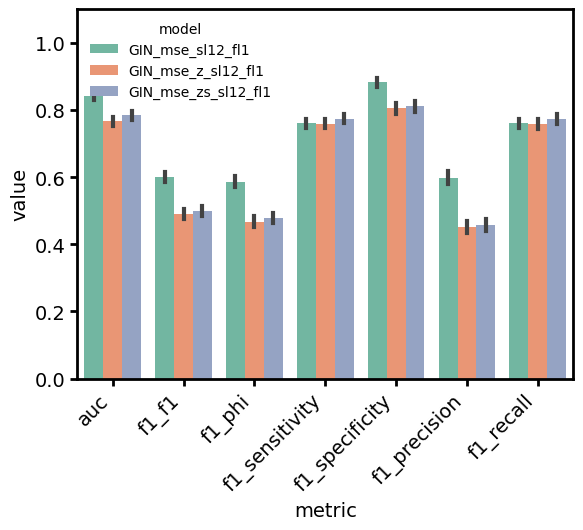

In [20]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: ('GIN' in x) and ('fl16' not in x) and ('sl12' in x))] #  ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
# plt.legend(loc='upper left')
plt.show()

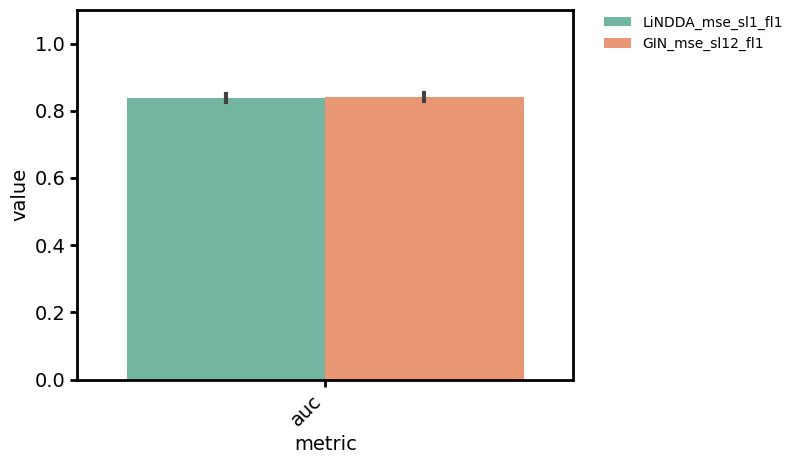

In [21]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and ('fl16' not in x) and (('_mse_s' in x) or ('_prob' in x)))]
metric_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

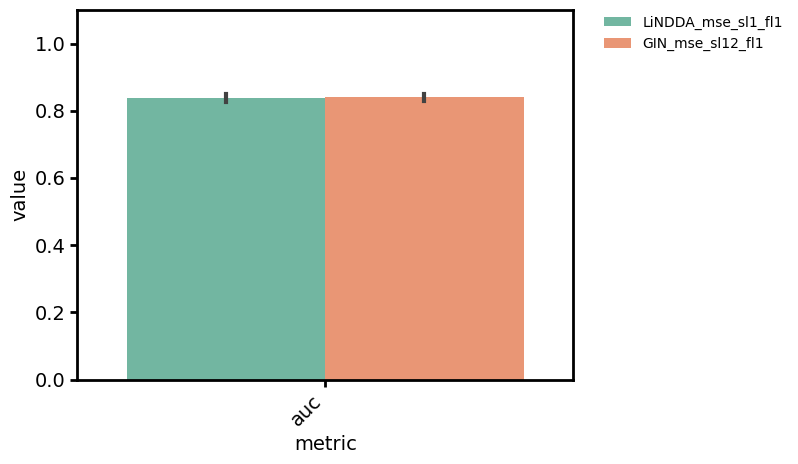

In [22]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and (('_mse_s' in x)))]
metric_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

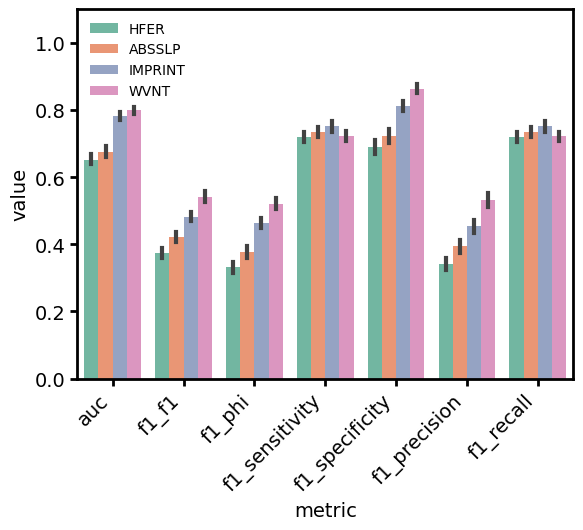

In [23]:
benchmark_data = pd.read_csv(ospj(prodatapath, 'benchmark_model_validation_results.csv'))
benchmark_data = benchmark_data[benchmark_data.onset.isin(ndd_data.onset)]
benchmark_melted = benchmark_data.melt(id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')

sns.barplot(x='metric',y='value',hue='model',data=benchmark_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(loc='upper left')
plt.show()

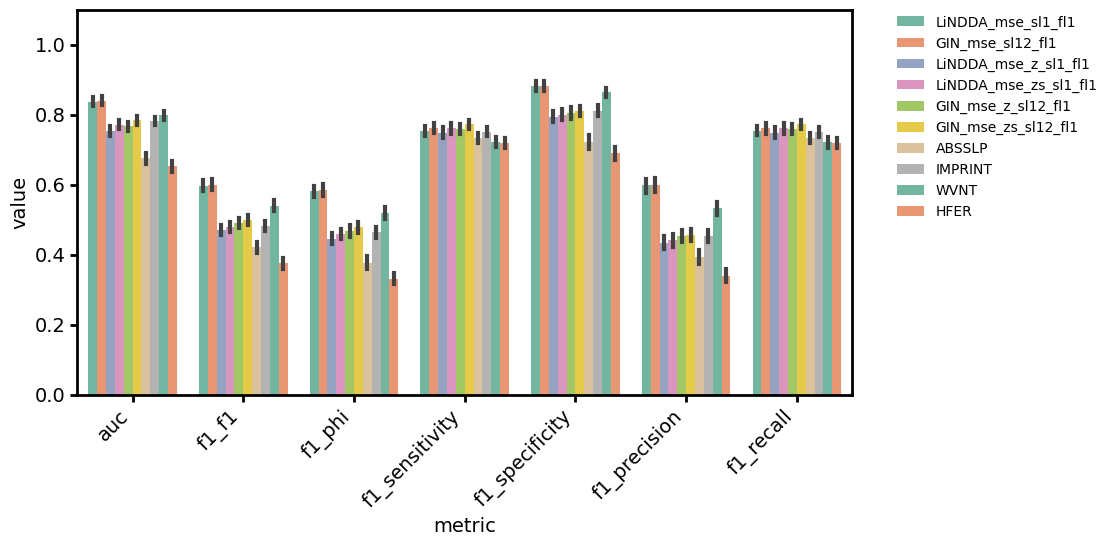

In [24]:
all_data = pd.concat([ndd_melted,benchmark_melted],axis=0).reset_index(drop=True)
fig,ax = plt.subplots(figsize=(10,5))
sns.barplot(x='metric',y='value',hue='model',data=all_data,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

In [25]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_data.groupby(['metric', 'model'])['value'].median().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
            metric                  model     value
0              auc       GIN_mse_sl12_fl1  0.922984
1              auc     LiNDDA_mse_sl1_fl1  0.920777
2              auc                   WVNT  0.859477
3              auc    GIN_mse_zs_sl12_fl1  0.855940
4              auc     GIN_mse_z_sl12_fl1  0.836928
5            f1_f1       GIN_mse_sl12_fl1  0.615385
6            f1_f1     LiNDDA_mse_sl1_fl1  0.600000
7            f1_f1                   WVNT  0.571429
8            f1_f1     GIN_mse_z_sl12_fl1  0.500000
9            f1_f1    GIN_mse_zs_sl12_fl1  0.500000
10          f1_phi       GIN_mse_sl12_fl1  0.611714
11          f1_phi     LiNDDA_mse_sl1_fl1  0.611714
12          f1_phi                   WVNT  0.559202
13          f1_phi    GIN_mse_zs_sl12_fl1  0.491766
14          f1_phi     GIN_mse_z_sl12_fl1  0.488334
15    f1_precision       GIN_mse_sl12_fl1  0.625000
16    f1_precision     LiNDDA_mse_sl1_fl1  0.625000
17    f1_precision                

In [26]:
iou_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index().groupby('model').agg({'iou_threshold':'mean'}).reset_index()
f1_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'f1_threshold':'mean'}).reset_index().groupby('model').agg({'f1_threshold':'mean'}).reset_index()
phi_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'phi_threshold':'mean'}).reset_index().groupby('model').agg({'phi_threshold':'mean'}).reset_index()
print(iou_ndd_thresholds)
print(f1_ndd_thresholds)

                   model  iou_threshold
0       GIN_mse_sl12_fl1       0.913875
1     GIN_mse_z_sl12_fl1       6.039044
2    GIN_mse_zs_sl12_fl1       5.721965
3     LiNDDA_mse_sl1_fl1       0.898001
4   LiNDDA_mse_z_sl1_fl1       5.607876
5  LiNDDA_mse_zs_sl1_fl1       5.250589
                   model  f1_threshold
0       GIN_mse_sl12_fl1      0.948297
1     GIN_mse_z_sl12_fl1      6.608872
2    GIN_mse_zs_sl12_fl1      6.147154
3     LiNDDA_mse_sl1_fl1      0.939776
4   LiNDDA_mse_z_sl1_fl1      6.412339
5  LiNDDA_mse_zs_sl1_fl1      6.006190


In [29]:
f1_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_f1_v2.csv'))
iou_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_iou_v2.csv'))
phi_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_phi_v2.csv'))

## NDD generalization performance

In [2]:
thresh_key = 'iou'
benchmark_val = pd.read_csv(ospj(prodatapath, f"benchmark_val_analysis_results_{thresh_key}.csv"))
ndd_val = pd.read_csv(ospj(prodatapath, f"ndd_spread_analysis_results_{thresh_key}_v2.csv"), on_bad_lines='warn')
ndd_val = ndd_val[(ndd_val.model.apply(lambda x: (('GIN' in x) or ('LiN' in x)) and (('_mse_s' in x)) and (('sl1' in x) or ('sl12' in x)) and ('fl16' not in x))) & (ndd_val.model_name.apply(lambda x: 'tau' not in x))]
mdl_map = {'LiNDDA_mse_sl1_fl1':'LiNDDA','GIN_mse_sl12_fl1':'NDD'}
ndd_val['model'] = ndd_val['model'].map(mdl_map)
benchmark_val = benchmark_val[benchmark_val.onset.isin(ndd_val.onset)]
all_val = pd.concat([benchmark_val,ndd_val])
na_list = ['f1','phi','sensitivity','specificity','precision','recall']
all_val[na_list] = all_val[na_list].fillna(0)
print(all_val.onset.nunique())
print(all_val.patient.nunique())
avg_seizures_per_patient = all_val.groupby('patient').onset.nunique()
print("Average seizures per patient:", avg_seizures_per_patient.mean())
print("Std seizures per patient:", avg_seizures_per_patient.std())
# all_val = ndd_val
all_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['auc','f1','phi','sensitivity','specificity','precision'], var_name='metric', value_name='value')

1017
107
Average seizures per patient: 9.523364485981308
Std seizures per patient: 17.03733181475012


In [3]:
ndd_val.groupby(['model','patient'],as_index=False)['nsoz'].apply(lambda x: np.nanmean(x)).groupby('model',as_index=False)['nsoz'].mean()

/tmp/ipykernel_858/2785548357.py:1: RuntimeWarning: Mean of empty slice
  ndd_val.groupby(['model','patient'],as_index=False)['nsoz'].apply(lambda x: np.nanmean(x)).groupby('model',as_index=False)['nsoz'].mean()


,model,nsoz
0,LiNDDA,0.544057
1,NDD,0.535944


In [4]:
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','LiNDDA', 'NDD']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#ff7f00','#a65628']
# color_palette = ['#f5ecdc', '#c4d5a7', '#7dbc95', '#469c9c', '#665b7f', '#4fc3e6', '#5673b6']
# color_palette = ['#ffe78e', '#b8db7d', '#60ccc8', '#379cac', '#38598c', '#2c2251', '#2d1737']
# color_palette = ['#fcfdbf', '#daea6f', '#a8c96a', '#74a268', '#447484', '#38598c', '#00202c']
# color_palette = ['#f6e8aa', '#b1e47d', '#57c899', '#4398b9', '#665b7f', '#423c76', '#372944']

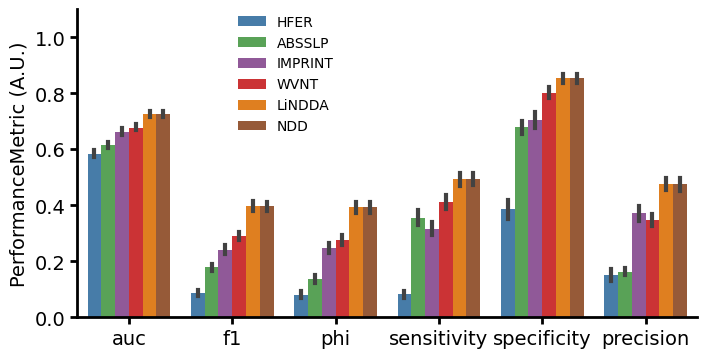

In [8]:
plt.figure(figsize=(8,4))
sns.barplot(x='metric',y='value',hue='model',data=all_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0
)
# sns.stripplot(x='metric',y='value',hue='model',data=all_val_melted,
# palette = ['grey','grey','grey','grey','grey','grey'],
# size=1,
# alpha=0.2,
# legend=False,
# dodge=True
# )
plt.legend(loc='upper left', bbox_to_anchor=(0.25, 1), borderaxespad=0.)
plt.ylim([0,1.1])
plt.xlabel('')
plt.ylabel('PerformanceMetric (A.U.)')
sns.despine()
plt.show()

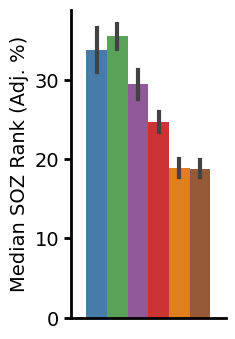

In [9]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['adj_med_soz_spread_rank_pct'], var_name='metric', value_name='value')
plt.figure(figsize=(2,4))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False
)
# plt.legend(bbox_to_anchor=(0.795, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('')
plt.xticks([])
plt.ylabel('Median SOZ Rank (Adj. %)')

sns.despine()

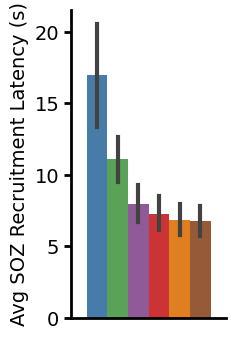

In [10]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['avg_soz_recruitment_latency'], var_name='metric', value_name='value')

plt.figure(figsize=(2,4))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False
)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.ylabel('Avg SOZ Recruitment Latency (s)')
plt.xlabel('')
plt.xticks([])
sns.despine()
plt.show()

In [51]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_val_melted.groupby(['metric', 'model'])['value'].mean().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
         metric    model     value
0           auc      NDD  0.723417
1           auc   LiNDDA  0.721524
2           auc     WVNT  0.676754
3           auc  IMPRINT  0.655071
4           auc   ABSSLP  0.623074
5            f1      NDD  0.399218
6            f1   LiNDDA  0.396380
7            f1     WVNT  0.294486
8            f1  IMPRINT  0.229556
9            f1   ABSSLP  0.197086
10          phi      NDD  0.397951
11          phi   LiNDDA  0.394462
12          phi     WVNT  0.282524
13          phi  IMPRINT  0.234814
14          phi   ABSSLP  0.163717
15    precision      NDD  0.491247
16    precision   LiNDDA  0.487137
17    precision  IMPRINT  0.362792
18    precision     WVNT  0.359192
19    precision   ABSSLP  0.204835
20  sensitivity      NDD  0.485741
21  sensitivity   LiNDDA  0.480096
22  sensitivity     WVNT  0.404563
23  sensitivity   ABSSLP  0.327843
24  sensitivity  IMPRINT  0.292114
25  specificity      NDD  0.859586
26  specificity   LiNDDA 

## Test set performance

In [133]:
test_data = pd.read_csv(ospj(prodatapath,'test_validation_results_channels.csv'))
# test_data = test_data[test_data.patient.apply(lambda x: 'HUP' in x)]
# test_data['model_name'] = test_data['model_name'].map({'GIN':'NDD'})
# test_data['model'] = test_data.pop('model_name')
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','LiNDDA', 'GIN','Interrater']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#ff7f00','#a65628','gray']

In [134]:
test_data.columns

Index(['patient', 'onset', 'model_name', 'model_key', 'full_model_key',
       'sequence_length', 'forecast_length', 'metric',
       'onset_inter_rater_reliability', 'spread_inter_rater_reliability',
       'avg_soz_prob', 'avg_nsoz_prob', 'onset_auc', 'spread_auc',
       'optimal_phi_threshold', 'phi_at_optimal_threshold',
       'onset_phi_annotators_at_optimal', 'spread_phi_annotators_at_optimal',
       'learned_phi_threshold', 'onset_phi_at_learned_phi',
       'spread_phi_at_learned_phi', 'onset_phi_annotators_at_learned_phi',
       'learned_f1_threshold', 'onset_phi_at_learned_f1',
       'spread_phi_at_learned_f1', 'onset_phi_annotators_at_learned_f1',
       'learned_iou_threshold', 'onset_phi_at_learned_iou',
       'spread_phi_at_learned_iou', 'onset_phi_annotators_at_learned_iou'],
      dtype='object')

In [135]:
# Assume test_data is loaded and has columns including: 'patient', 'onset', 'model_name', and 'phi_at_optimal_threshold'

# Create a new "interrater" DataFrame with unique (patient, onset) pairs, setting
# phi_at_optimal_threshold to onset_inter_rater_reliability for each pair

cols = list(test_data.columns)

if 'onset_inter_rater_reliability' not in test_data.columns:
    raise ValueError("No column found for onset_inter_rater_reliability value.")

# Get unique patient/onset pairs and their onset_inter_rater_reliability
unique_pairs = test_data[['patient', 'onset', 'onset_inter_rater_reliability']].drop_duplicates()

# Create a new DataFrame for interrater results
interrater_rows = []
for _, row in unique_pairs.iterrows():
    new_row = {col: None for col in cols}
    new_row['patient'] = row['patient']
    new_row['onset'] = row['onset']
    new_row['model_name'] = 'Interrater'
    # Put the onset_inter_rater_reliability into phi_at_optimal_threshold
    new_row['phi_at_optimal_threshold'] = row['onset_inter_rater_reliability']
    # Assign the reliability value to the desired columns
    for colname in ['onset_phi_at_learned_phi', 'onset_phi_at_learned_f1', 'onset_phi_at_learned_iou']:
        if colname in cols:
            new_row[colname] = row['onset_inter_rater_reliability']
    # Also copy onset_inter_rater_reliability column for clarity
    if 'onset_inter_rater_reliability' in cols:
        new_row['onset_inter_rater_reliability'] = row['onset_inter_rater_reliability']
    interrater_rows.append(new_row)

interrater_df = pd.DataFrame(interrater_rows, columns=cols)
test_data_interrater = pd.concat([test_data, interrater_df], ignore_index=True)

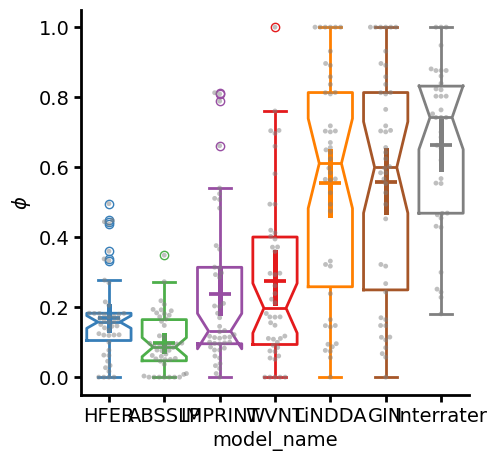

In [136]:
phi_key = 'phi_at_optimal_threshold'
# phi_key = 'onset_phi_at_learned_phi'
# phi_key = 'onset_auc'
plt.subplots(figsize=(5,5))
sns.boxplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',
notch=True,
fill=False,
palette = color_palette,
hue_order = hue_order,
order = hue_order
)
plt.ylabel('$\phi$')
sns.pointplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',estimator='mean',
linestyle='none',
marker='_',
markersize=16,
palette = color_palette,
hue_order = hue_order,
order = hue_order
)
sns.swarmplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',palette=['gray']*7,size=3.5,alpha=0.5)
sns.despine()

In [141]:
import statsmodels.formula.api as smf
for key1,key2 in zip(['GIN'] * 5 + ['LiNDDA'] * 5,['HFER','ABSSLP','IMPRINT','WVNT','Interrater']*2):
    # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
    lme_data = test_data_interrater[
        test_data_interrater['model_name'].isin([key1, key2])
    ].copy()
    lme_data = lme_data[
        lme_data['phi_at_optimal_threshold'].notnull() &
        lme_data['patient'].notnull()
    ]

    # Ensure patient is treated as a categorical
    lme_data['patient'] = lme_data['patient'].astype(str)

    # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
    pivot = lme_data.pivot_table(
        index=['patient', 'onset'], 
        columns='model_name', 
        values='phi_at_optimal_threshold'
    ).reset_index()

    # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
    pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
    pivot['phi_diff'] = pivot[key1] - pivot[key2]

    # Prepare data for modeling
    diff_data = pivot[['patient', 'phi_diff']].copy()

    # Fit the LME model: phi_diff ~ 1 + (1|patient)
    md = smf.mixedlm(
        "phi_diff ~ 1",
        diff_data,
        groups=diff_data["patient"]
    )
    lme_model = md.fit()
    print(key1,', ',key2, lme_model.pvalues['Intercept'])
    # print(lme_model.summary())



GIN ,  HFER 1.5592038388504624e-06
GIN ,  ABSSLP 4.677385646051312e-10
GIN ,  IMPRINT 1.08452966031095e-08
GIN ,  WVNT 3.966421216547471e-05
GIN ,  Interrater 0.12492699695840319
LiNDDA ,  HFER 2.303805947302675e-06
LiNDDA ,  ABSSLP 8.888901697590216e-10
LiNDDA ,  IMPRINT 3.5127224992115245e-08
LiNDDA ,  WVNT 5.11578835353865e-05
LiNDDA ,  Interrater 0.11733746300587052


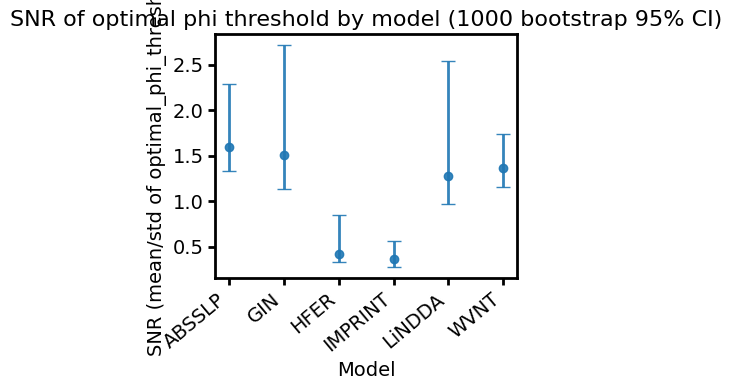

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Restrict to just test_data (not the interrater-augmented DataFrame)
snr_results = []
n_boot = 1000
rng = np.random.default_rng(42)

for model in test_data['model_name'].unique():
    vals = test_data.loc[
        test_data['model_name'] == model, 'optimal_phi_threshold' if 'optimal_phi_threshold' in test_data.columns else 'phi_at_optimal_threshold'
    ].dropna().values
    if len(vals) < 2:
        continue
    mean = np.nanmean(vals)
    std = np.nanstd(vals, ddof=1)
    if std == 0:
        continue
    snr = mean / std

    # Bootstrap CIs
    snr_boots = []
    for _ in range(n_boot):
        boot = rng.choice(vals, size=len(vals), replace=True)
        boot_mean = np.nanmean(boot)
        boot_std = np.nanstd(boot, ddof=1)
        if boot_std > 0:
            snr_boots.append(boot_mean / boot_std)
    if not snr_boots:
        continue
    ci_lower, ci_upper = np.percentile(snr_boots, [2.5, 97.5])

    snr_results.append({
        'model': model,
        'snr': snr,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'n': len(vals)
    })

snr_df = pd.DataFrame(snr_results)
snr_df = snr_df.sort_values('model')

fig, ax = plt.subplots(figsize=(4, 4))
xvals = np.arange(len(snr_df))
ax.errorbar(
    xvals,
    snr_df['snr'],
    yerr=[snr_df['snr'] - snr_df['ci_lower'], snr_df['ci_upper'] - snr_df['snr']],
    fmt='o',
    capsize=5,
    color='C0',
    alpha=0.9,
)
ax.set_xticks(xvals)
ax.set_xticklabels(snr_df['model'], rotation=40, ha='right')
ax.set_xlabel('Model')
ax.set_ylabel('SNR (mean/std of optimal_phi_threshold)')
ax.set_title('SNR of optimal phi threshold by model (1000 bootstrap 95% CI)')
plt.tight_layout()
plt.show()




## Visualization

In [13]:
test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob','HUP224','HUP224_task-ictal519177_run-00_mdl-ABSSLP_sz_prob.pkl'))
# test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP238/HUP238_task-ictal290006_run-00_mdl-HFER_sz_prob.pkl'))
prob_times = test_mat.pop('time')
# test_mat /= 100

In [23]:
test_mat.loc[370:376,['RB01-RB02']]

,RB01-RB02
370,292.545001
371,345.058369
372,373.151875
373,355.115855
374,319.210073
375,243.186362
376,197.988020


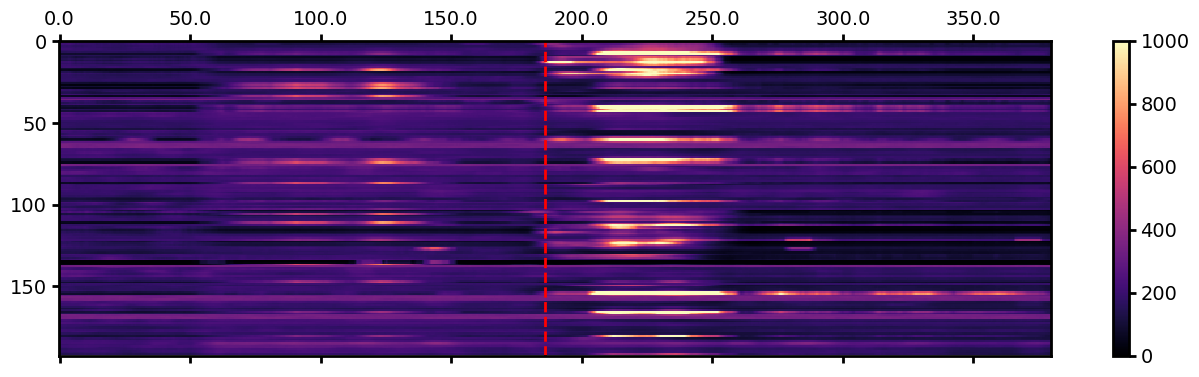

In [21]:
plt.matshow(sc.ndimage.uniform_filter1d(test_mat.T,20,axis=1),aspect='auto',cmap='magma',
clim=(0,1000)
)
plt.xticks(ticks=np.arange(0, len(prob_times), 100), labels=prob_times.to_numpy()[::100].round(0))
onset_idx = np.argmin(np.abs(prob_times-186))
plt.axvline(onset_idx,linestyle='--',color='red')
plt.colorbar()
plt.show()


In [19]:
onset_idx

366